In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

C:\Users\Riyad\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
C:\Users\Riyad\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Device: cuda


In [2]:
# Load data
train_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/train_final.csv')
val_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/val_final.csv')
test_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/test_final.csv')
nlp_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/step7_nlp_features.csv')

# Text combine
train_df['text'] = train_df['headline'].fillna('') + ' ' + train_df['content'].fillna('')
val_df['text'] = val_df['headline'].fillna('') + ' ' + val_df['content'].fillna('')
test_df['text'] = test_df['headline'].fillna('') + ' ' + test_df['content'].fillna('')

# Label
label2id = {'authentic': 0, 'fake': 1, 'ai_fake': 2}
train_df['label_id'] = train_df['label'].map(label2id)
val_df['label_id'] = val_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)

print(" Data loaded!")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"NLP features shape: {nlp_df.shape}")
print(f"NLP columns: {nlp_df.columns.tolist()}")

 Data loaded!
Train: 10500, Val: 2250, Test: 2250
NLP features shape: (15000, 11)
NLP columns: ['headline', 'content', 'label', 'text', 'token_count', 'noun_count', 'verb_count', 'adjective_count', 'unique_pos_count', 'ner_count', 'ner_ratio']


In [3]:
# NLP feature columns
nlp_features = ['token_count', 'noun_count', 'verb_count', 
                'adjective_count', 'unique_pos_count', 'ner_count', 'ner_ratio']

# Split nlp_df same as train/val/test
nlp_train = nlp_df.iloc[:10500].reset_index(drop=True)
nlp_val = nlp_df.iloc[10500:12750].reset_index(drop=True)
nlp_test = nlp_df.iloc[12750:].reset_index(drop=True)

# Scale features
scaler = StandardScaler()
train_nlp = scaler.fit_transform(nlp_train[nlp_features])
val_nlp = scaler.transform(nlp_val[nlp_features])
test_nlp = scaler.transform(nlp_test[nlp_features])

print(" NLP features ready!")
print(f"Train NLP shape: {train_nlp.shape}")
print(f"Val NLP shape: {val_nlp.shape}")
print(f"Test NLP shape: {test_nlp.shape}")

 NLP features ready!
Train NLP shape: (10500, 7)
Val NLP shape: (2250, 7)
Test NLP shape: (2250, 7)


In [4]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")
print(" Tokenizer loaded!")

# Dataset class
class FusionDataset(Dataset):
    def __init__(self, texts, nlp_feats, labels, tokenizer, max_len=128):
        self.texts = texts
        self.nlp_feats = nlp_feats
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'nlp_feats': torch.tensor(self.nlp_feats[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print(" Dataset class ready!")

 Tokenizer loaded!
 Dataset class ready!


In [5]:
# Fusion Model
class FusionModel(nn.Module):
    def __init__(self, nlp_feat_dim=7, hidden_dim=64, num_labels=3):
        super().__init__()
        self.bert = AutoModel.from_pretrained("csebuetnlp/banglabert")
        self.mlp = nn.Sequential(
            nn.Linear(nlp_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(768 + hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask, nlp_feats):
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls = bert_out.last_hidden_state[:, 0, :]
        nlp_out = self.mlp(nlp_feats)
        combined = torch.cat([cls, nlp_out], dim=1)
        return self.classifier(combined)

print(" Model class ready!")

 Model class ready!


In [7]:
# Train & Evaluate function
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

def run_experiment(train_nlp_feats, val_nlp_feats, test_nlp_feats, nlp_feat_dim, exp_name):
    print(f"\n{'='*50}")
    print(f"Experiment: {exp_name}")
    print(f"{'='*50}")

    # Datasets
    train_ds = FusionDataset(train_df['text'].values, train_nlp_feats, train_df['label_id'].values, tokenizer)
    val_ds = FusionDataset(val_df['text'].values, val_nlp_feats, val_df['label_id'].values, tokenizer)
    test_ds = FusionDataset(test_df['text'].values, test_nlp_feats, test_df['label_id'].values, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16)
    test_loader = DataLoader(test_ds, batch_size=16)

    # Model
    model = FusionModel(nlp_feat_dim=nlp_feat_dim).to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * 3
    scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

    # Train
    best_f1 = 0
    best_test_f1 = 0

    for epoch in range(3):
        model.train()
        total_loss = 0
        criterion = nn.CrossEntropyLoss()

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            nlp_f = batch['nlp_feats'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, nlp_f)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        # Evaluate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                nlp_f = batch['nlp_feats'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids, attention_mask, nlp_f)
                preds = outputs.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true, val_preds, average='macro')
        print(f"Epoch {epoch+1}/3 | Loss: {total_loss/len(train_loader):.4f} | Val F1: {val_f1*100:.2f}%")

        if val_f1 > best_f1:
            best_f1 = val_f1
            # Test
            test_preds, test_true = [], []
            with torch.no_grad():
                for batch in test_loader:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    nlp_f = batch['nlp_feats'].to(device)
                    labels = batch['label'].to(device)
                    outputs = model(input_ids, attention_mask, nlp_f)
                    preds = outputs.argmax(dim=1)
                    test_preds.extend(preds.cpu().numpy())
                    test_true.extend(labels.cpu().numpy())
            best_test_f1 = f1_score(test_true, test_preds, average='macro')
            print(f"\nBest Val F1: {best_f1*100:.2f}%")
    print(f"Best Test F1: {best_test_f1*100:.2f}%")
    return best_f1, best_test_f1

print(" Function ready!")



 Function ready!


In [8]:

results = {}

# 1. Full Model 
val_f1, test_f1 = run_experiment(
    train_nlp, val_nlp, test_nlp,
    nlp_feat_dim=7,
    exp_name="Full Fusion (All 7 features)"
)
results["Full Fusion"] = {"val": val_f1, "test": test_f1}


Experiment: Full Fusion (All 7 features)
Epoch 1/3 | Loss: 0.3867 | Val F1: 89.72%

Best Val F1: 89.72%
Epoch 2/3 | Loss: 0.2313 | Val F1: 91.82%

Best Val F1: 91.82%
Epoch 3/3 | Loss: 0.1663 | Val F1: 92.39%

Best Val F1: 92.39%
Best Test F1: 91.33%


In [9]:

features_no_token = ['noun_count', 'verb_count', 
                     'adjective_count', 'unique_pos_count', 
                     'ner_count', 'ner_ratio']

train_no_token = scaler.fit_transform(nlp_train[features_no_token])
val_no_token = scaler.transform(nlp_val[features_no_token])
test_no_token = scaler.transform(nlp_test[features_no_token])

val_f1, test_f1 = run_experiment(
    train_no_token, val_no_token, test_no_token,
    nlp_feat_dim=6,
    exp_name="w/o token_count"
)
results["w/o token_count"] = {"val": val_f1, "test": test_f1}


Experiment: w/o token_count
Epoch 1/3 | Loss: 0.3759 | Val F1: 89.77%

Best Val F1: 89.77%
Epoch 2/3 | Loss: 0.2190 | Val F1: 91.30%

Best Val F1: 91.30%
Epoch 3/3 | Loss: 0.1467 | Val F1: 92.70%

Best Val F1: 92.70%
Best Test F1: 91.77%


In [10]:

features_no_ner = ['token_count', 'noun_count', 'verb_count', 
                   'adjective_count', 'unique_pos_count']

train_no_ner = scaler.fit_transform(nlp_train[features_no_ner])
val_no_ner = scaler.transform(nlp_val[features_no_ner])
test_no_ner = scaler.transform(nlp_test[features_no_ner])

val_f1, test_f1 = run_experiment(
    train_no_ner, val_no_ner, test_no_ner,
    nlp_feat_dim=5,
    exp_name="w/o NER features"
)
results["w/o NER features"] = {"val": val_f1, "test": test_f1}


Experiment: w/o NER features
Epoch 1/3 | Loss: 0.3810 | Val F1: 90.47%

Best Val F1: 90.47%
Epoch 2/3 | Loss: 0.2224 | Val F1: 91.40%

Best Val F1: 91.40%
Epoch 3/3 | Loss: 0.1637 | Val F1: 92.44%

Best Val F1: 92.44%
Best Test F1: 91.77%


In [11]:
# 4. POS features 
features_no_pos = ['token_count', 'ner_count', 'ner_ratio']

train_no_pos = scaler.fit_transform(nlp_train[features_no_pos])
val_no_pos = scaler.transform(nlp_val[features_no_pos])
test_no_pos = scaler.transform(nlp_test[features_no_pos])

val_f1, test_f1 = run_experiment(
    train_no_pos, val_no_pos, test_no_pos,
    nlp_feat_dim=3,
    exp_name="w/o POS features"
)
results["w/o POS features"] = {"val": val_f1, "test": test_f1}


Experiment: w/o POS features
Epoch 1/3 | Loss: 0.3782 | Val F1: 90.58%

Best Val F1: 90.58%
Epoch 2/3 | Loss: 0.2185 | Val F1: 91.34%

Best Val F1: 91.34%
Epoch 3/3 | Loss: 0.1607 | Val F1: 92.43%

Best Val F1: 92.43%
Best Test F1: 91.59%


In [12]:
# 5. token_count
features_only_token = ['token_count']

train_only_token = scaler.fit_transform(nlp_train[features_only_token])
val_only_token = scaler.transform(nlp_val[features_only_token])
test_only_token = scaler.transform(nlp_test[features_only_token])

val_f1, test_f1 = run_experiment(
    train_only_token, val_only_token, test_only_token,
    nlp_feat_dim=1,
    exp_name="Only token_count"
)
results["Only token_count"] = {"val": val_f1, "test": test_f1}


Experiment: Only token_count
Epoch 1/3 | Loss: 0.3898 | Val F1: 89.74%

Best Val F1: 89.74%
Epoch 2/3 | Loss: 0.2213 | Val F1: 90.95%

Best Val F1: 90.95%
Epoch 3/3 | Loss: 0.1518 | Val F1: 92.25%

Best Val F1: 92.25%
Best Test F1: 91.81%


In [13]:
# 6. BanglaBERT only 
# dummy 1-dim zero features
train_zero = np.zeros((len(train_df), 1))
val_zero = np.zeros((len(val_df), 1))
test_zero = np.zeros((len(test_df), 1))

val_f1, test_f1 = run_experiment(
    train_zero, val_zero, test_zero,
    nlp_feat_dim=1,
    exp_name="BanglaBERT Only"
)
results["BanglaBERT Only"] = {"val": val_f1, "test": test_f1}


Experiment: BanglaBERT Only
Epoch 1/3 | Loss: 0.3775 | Val F1: 90.30%

Best Val F1: 90.30%
Epoch 2/3 | Loss: 0.2086 | Val F1: 92.66%

Best Val F1: 92.66%
Epoch 3/3 | Loss: 0.1344 | Val F1: 93.24%

Best Val F1: 93.24%
Best Test F1: 92.08%


In [14]:
# Final Results Table
print("\n" + "="*60)
print("ABLATION STUDY RESULTS")
print("="*60)
print(f"{'Configuration':<25} {'Val F1':>10} {'Test F1':>10}")
print("-"*60)
for name, scores in results.items():
    print(f"{name:<25} {scores['val']*100:>9.2f}% {scores['test']*100:>9.2f}%")
print("="*60)

# Save results
import json
with open('C:/Users/Riyad/projects/fake_news/ablation_results.json', 'w') as f:
    json.dump(results, f)
print(" Results saved!")


ABLATION STUDY RESULTS
Configuration                 Val F1    Test F1
------------------------------------------------------------
Full Fusion                   92.39%     91.33%
w/o token_count               92.70%     91.77%
w/o NER features              92.44%     91.77%
w/o POS features              92.43%     91.59%
Only token_count              92.25%     91.81%
BanglaBERT Only               93.24%     92.08%
 Results saved!


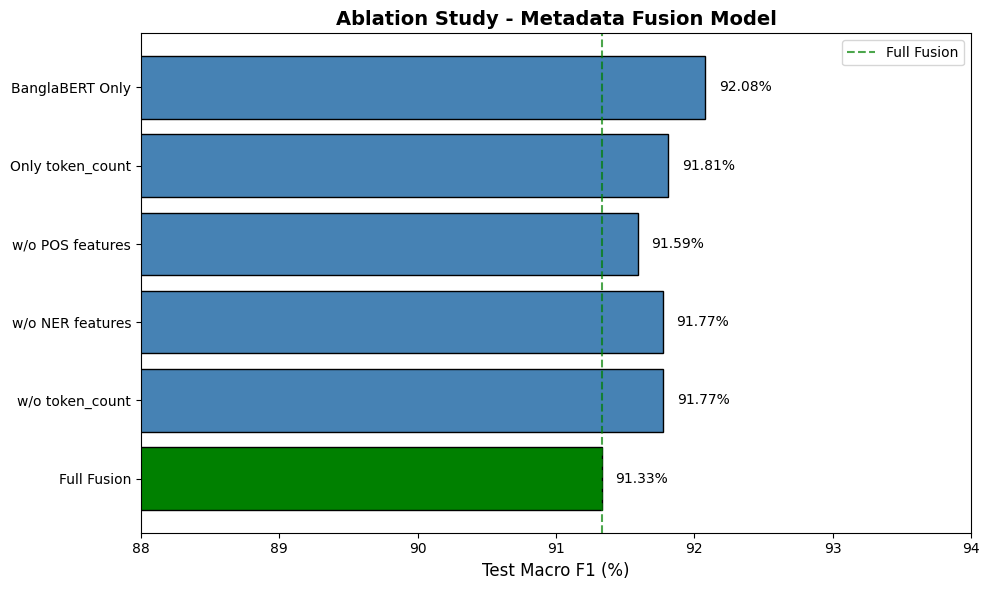

 Chart saved!


In [15]:
import matplotlib.pyplot as plt
import numpy as np

configs = list(results.keys())
test_f1s = [results[k]['test']*100 for k in configs]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if i == 0 else 'steelblue' for i in range(len(configs))]
bars = ax.barh(configs, test_f1s, color=colors, edgecolor='black')

# Value labels
for bar, val in zip(bars, test_f1s):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Test Macro F1 (%)', fontsize=12)
ax.set_title('Ablation Study - Metadata Fusion Model', fontsize=14, fontweight='bold')
ax.set_xlim(88, 94)
ax.axvline(x=results['Full Fusion']['test']*100, 
           color='green', linestyle='--', alpha=0.7, label='Full Fusion')
ax.legend()
plt.tight_layout()
plt.savefig('C:/Users/Riyad/projects/fake_news/ablation_study.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print(" Chart saved!")